# GPT & Language Models

把前课的理论拼成真正能训练、能生成的语言模型：字符级 GPT（自回归 + 交叉熵），训练后看它"学会"语法并采样生成。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 语言建模任务


预测**下一个 token**：给定上下文 $x_1,\dots,x_t$，输出 $P(x_{t+1}|x_1,\dots,x_t)$。整句概率 = 逐 token 条件概率连乘（链式法则，概率 03）：

$$P(x_1, \dots, x_T) = \prod_{t=1}^{T} P(x_t \,|\, x_{<t})$$

**GPT = decoder-only Transformer**：把下一 token 预测变成自回归生成。训练损失就是交叉熵（= 负对数似然）。


## 2. 数据：字符级语料


用一段带语法结构的合成英文构造字符级数据集（小到 CPU 秒级训练，结构清晰到能看出模型学会规律）。


In [2]:
text_base = ("the cat sat on the mat and the dog ran in the park "
             "the bird sang in the tree the fox jumped over the fence "
             "the sun rose in the east the rain fell on the roof ")
text = text_base * 40                     # 重复 → 语料有清晰统计规律
chars = sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}; itos = {i: c for c, i in stoi.items()}
V = len(chars)
data = torch.tensor([stoi[c] for c in text])
print(f"词表大小 V = {V}，语料长度 = {len(data)}")
print("字符表:", chars)

seq_len = 16
n = len(data)
Xs = torch.stack([data[i:i+seq_len] for i in range(n - seq_len)])        # (M, seq_len)
Ys = torch.stack([data[i+1:i+seq_len+1] for i in range(n - seq_len)])    # (M, seq_len)：每个位置的下一个字符
print(f"样本: {len(Xs)} 个，每个 {seq_len} 字符 → 预测下一个字符")
print(f"Xs 形状: {tuple(Xs.shape)}，Ys 形状: {tuple(Ys.shape)}")


词表大小 V = 23，语料长度 = 6320
字符表: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'x']
样本: 6304 个，每个 16 字符 → 预测下一个字符
Xs 形状: (6304, 16)，Ys 形状: (6304, 16)


## 3. ToyGPT：Embedding + Block + LM Head


**Token Embedding**：把字符 id 映射成向量；**位置编码**：加正弦/可学习位置；**Transformer Block**：混合上下文；**LM Head**：输出词表上的 logits。


In [3]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model, self.n_heads = d_model, n_heads
        self.d_k = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model); self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model); self.Wo = nn.Linear(d_model, d_model)
    def forward(self, x, mask=None):
        B, T, _ = x.shape
        Q = self.Wq(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.Wk(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.Wv(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        out = attn @ V
        return self.Wo(out.transpose(1, 2).contiguous().view(B, T, self.d_model))

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        x = x + self.attn(self.norm1(x), mask)
        x = x + self.ff(self.norm2(x))
        return x

class ToyGPT(nn.Module):
    def __init__(self, V, d_model=48, n_heads=3, d_ff=96, n_layers=3):
        super().__init__()
        self.emb = nn.Embedding(V, d_model)
        self.pos = nn.Parameter(torch.zeros(512, d_model))     # 可学习位置编码
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, d_ff) for _ in range(n_layers)])
        self.lm = nn.Linear(d_model, V)
    def forward(self, idx):
        B, T = idx.shape
        x = self.emb(idx) + self.pos[:T]
        for blk in self.blocks:
            x = blk(x)
        return self.lm(x)

model = ToyGPT(V)
x0 = Xs[:4]
print("logits 形状:", tuple(model(x0).shape), "（B, T, V ✓）")
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")


logits 形状: (4, 16, 23) （B, T, V ✓）
参数量: 83,687


## 4. 训练：交叉熵 = 负对数似然


step    0  loss = 3.2076


step  200  loss = 0.5325


step  400  loss = 0.1838


step  600  loss = 0.0653


step  800  loss = 0.0292


step 1000  loss = 0.0142



最终 loss = 0.0142（随机猜测 ≈ 3.1355）


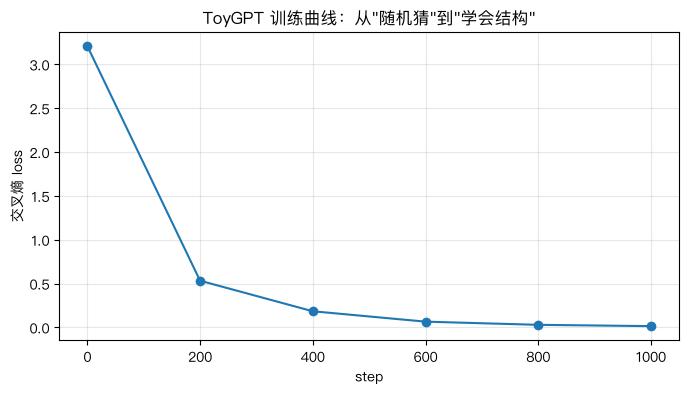

In [4]:
torch.manual_seed(0)
model = ToyGPT(V)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
losses = []
for step in range(1200):
    opt.zero_grad()
    idx = torch.randint(0, len(Xs), (64,))
    logits = model(Xs[idx])
    loss = F.cross_entropy(logits.reshape(-1, V), Ys[idx].reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)    # 梯度裁剪
    opt.step()
    if step % 200 == 0:
        losses.append((step, loss.item()))
        print(f"step {step:4d}  loss = {loss.item():.4f}")

print(f"\n最终 loss = {losses[-1][1]:.4f}（随机猜测 ≈ {np.log(V):.4f}）")
plt.figure(figsize=(8, 4))
ep, ls = zip(*losses)
plt.plot(ep, ls, 'o-')
plt.xlabel('step'); plt.ylabel('交叉熵 loss')
plt.title('ToyGPT 训练曲线：从"随机猜"到"学会结构"')
plt.grid(alpha=0.3)


## 5. 生成：温度采样


自回归生成：把上下文喂进模型 → 在输出分布上采样下一个 token → 拼回上下文继续。

**温度 $T$**：$p \propto e^{z/T}$。$T$ 小 → 贪心/锐利；$T$ 大 → 多样/混乱。**top-k**：只从前 $k$ 个候选里采，避免长尾噪声。


In [5]:
def generate(model, seed, n_chars=120, temperature=1.0, top_k=None):
    model.eval()
    idx = torch.tensor([stoi[c] for c in seed]).unsqueeze(0)
    out = list(seed)
    with torch.no_grad():
        for _ in range(n_chars):
            logits = model(idx[:, -seq_len:])[0, -1] / temperature
            if top_k:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[-1]] = float('-inf')
            probs = torch.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, 1).item()
            out.append(itos[nxt])
            idx = torch.cat([idx, torch.tensor([[nxt]])], dim=1)
    return ''.join(out)

print("T=0.5（保守）:", generate(model, "the cat ", 80, temperature=0.5), "\n")
print("T=1.0（平衡）:", generate(model, "the cat ", 80, temperature=1.0), "\n")
print("T=2.0（奔放）:", generate(model, "the cat ", 80, temperature=2.0))


T=0.5（保守）: the cat sooooooon on ooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo 

T=1.0（平衡）: the cat sat on the mat and the dog ran in the park the bird sang in the tree the fox jum 

T=2.0（奔放）: the cat sat on the mat and dog r ran in the iin the the jje fox joveeeeeeee ox thee the 


## 6. 从玩具到大模型


| 维度 | 本课 ToyGPT | 真实 GPT |
|------|------------|----------|
| 词表 | 20 字符 | 5 万+ BPE token |
| 参数 | ~6 万 | 十亿~万亿 |
| 数据 | 合成 2 千字符 | 万亿 token |
| 训练 | 秒级 CPU | 数月 GPU 集群 |

**架构没有本质区别**：embedding + 位置编码 + N 层 block + LM head + 交叉熵。规模、数据、工程（KV cache、并行、RLHF）拉开差距。**Tokenizer（BPE）**把词切成语义子单元，是真实系统的重要细节。


## 课后练习


1. **温度扫描**：对 T ∈ {0.2, 0.5, 1.0, 3.0} 各生成 3 段，统计每段的"重复率"随 T 的变化。
2. **top-k**：实现 top-k=3 与 top-k=50 对比生成质量。
3. **加深**：把 block 从 1 层改成 2 层，比较 loss 曲线。
4. **换语料**：把 text_base 换成"12345 12345"或"A B C"模式，观察模型学到的规律。
5. **思考**：为什么自回归损失（交叉熵）天然就是"下一个 token 预测"的负对数似然？
